In [6]:
import os
import json
import matplotlib.pyplot as plt

import xarray as xr
import seaborn as sns
import pandas as pd
import numpy as np

In [7]:
from pypalettes import load_cmap
cmap = load_cmap("highcontrast")
palette = cmap.colors

In [8]:
path = '/home/links/ct715/eddy_feedback/chapter1/cmip6/historical_runs/data/1979_2014/cmip6_hist_1979_2014_6h_efp_winters.csv'

df = pd.read_csv(path)
df

,model,efp_nh,efp_nh_gt3,efp_nh_123,efp_sh,efp_sh_gt3,efp_sh_123
0,ACCESS-CM2,0.259496,0.141086,0.129305,0.398165,0.302690,0.036845
1,ACCESS-ESM1-5,0.366614,0.169438,0.136643,0.271884,0.238321,0.032371
2,AWI-ESM-1-1-LR,0.278915,0.203647,0.091862,0.377607,0.340324,0.083725
3,BCC-CSM2-MR,0.300207,0.237454,0.096964,0.208682,0.232103,0.066063
4,CMCC-CM2-HR4,0.237483,0.174372,0.102620,0.278880,0.243473,0.044090
5,CMCC-CM2-SR5,0.295826,0.190414,0.143322,0.291259,0.275907,0.054451
6,CNRM-CM6-1-HR,0.120463,0.083723,0.037486,0.290063,0.214770,0.032383
7,EC-Earth3,0.303122,0.156528,0.110317,0.255611,0.135699,0.029813
8,EC-Earth3-AerChem,0.266665,0.126883,0.128966,0.315632,0.241320,0.025716
9,EC-Earth3-CC,0.294624,0.155916,0.159326,0.253074,0.176367,0.030282


---

# Reanalysis error bars

In [9]:
import pandas as pd
import numpy as np

BOOTSTRAP_CSV = '/home/links/ct715/eddy_feedback/chapter1/daily_efp/bootstrap/data/reanalysis/efp_500/jra55_efp_bootstrap_summary_efp_500.csv'

VAR_SEASON_TO_LABEL = {
    ('div1_QG_123', 'DJF'): 'EFP_nh_k123',
    ('div1_QG_gt3', 'DJF'): 'EFP_nh_k>3',
    ('div1_QG',     'DJF'): 'EFP_nh_total',
    ('div1_QG_123', 'JAS'): 'EFP_sh_k123',
    ('div1_QG_gt3', 'JAS'): 'EFP_sh_k>3',
    ('div1_QG',     'JAS'): 'EFP_sh_total',
}

_csv = pd.read_csv(BOOTSTRAP_CSV)
time_freq = '6h'
period = '1979_2016'

records = []
for (var, season), label in VAR_SEASON_TO_LABEL.items():
    case = f'{period}_{time_freq}_{var}'
    row  = _csv[(_csv['case'] == case) & (_csv['season'] == season)]
    if row.empty:
        print(f"Warning: no bootstrap data for {case} {season}")
        continue
    mean, std = row['efp_mean'].values[0], row['efp_std'].values[0]
    records.append({'efp_type': label, 'efp_mean': mean, 'efp_std': std})
    print(f"{label} ({case}): {mean:.3f}  [{mean - std:.3f}, {mean + std:.3f}]")

bootstrap_df = pd.DataFrame(records)
bootstrap_df

EFP_nh_k123 (1979_2016_6h_div1_QG_123): 0.186  [0.141, 0.232]
EFP_nh_k>3 (1979_2016_6h_div1_QG_gt3): 0.163  [0.127, 0.199]
EFP_nh_total (1979_2016_6h_div1_QG): 0.372  [0.316, 0.428]
EFP_sh_k123 (1979_2016_6h_div1_QG_123): 0.043  [0.025, 0.060]
EFP_sh_k>3 (1979_2016_6h_div1_QG_gt3): 0.242  [0.203, 0.280]
EFP_sh_total (1979_2016_6h_div1_QG): 0.277  [0.244, 0.311]


,efp_type,efp_mean,efp_std
0,EFP_nh_k123,0.186269,0.045370
1,EFP_nh_k>3,0.163150,0.036278
2,EFP_nh_total,0.371841,0.056274
3,EFP_sh_k123,0.042624,0.017403
4,EFP_sh_k>3,0.241764,0.038707
5,EFP_sh_total,0.277287,0.033308


/emmy-noether/home/ct715/miniforge3/envs/eddy/lib/python3.10/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/emmy-noether/home/ct715/miniforge3/envs/eddy/lib/python3.10/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/emmy-noether/home/ct715/miniforge3/envs/eddy/lib/python3.10/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


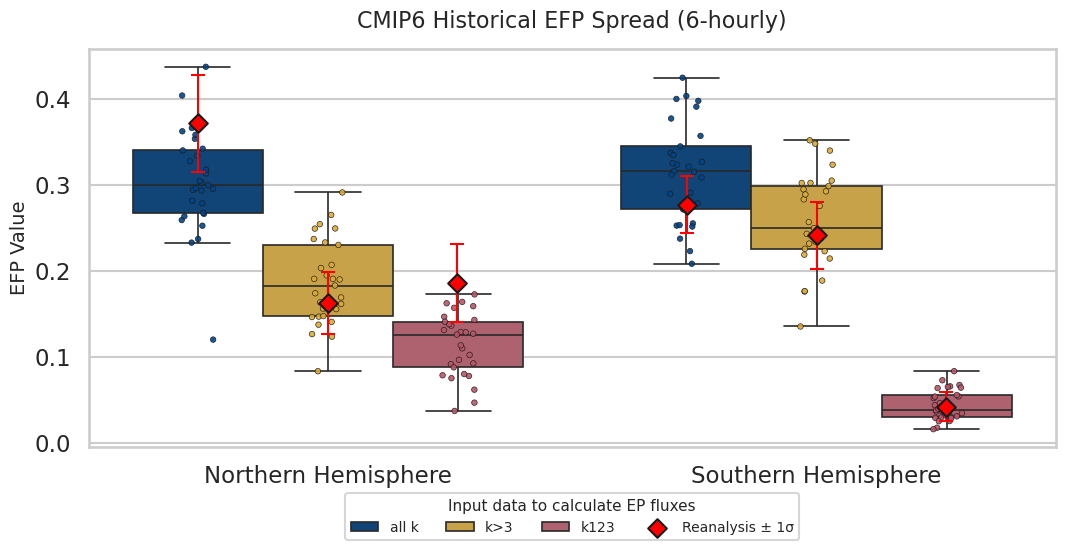

In [10]:
# Convert to discrete palette for seaborn
# palette = sns.color_palette(cmap, n_colors=3)

# Melt to long format for seaborn
df_long = df.melt(
    id_vars="model",
    value_vars=["efp_nh", "efp_nh_gt3", "efp_nh_123", "efp_sh", "efp_sh_gt3", "efp_sh_123"],
    var_name="hemisphere_dataset", value_name="efp"
)

# Split hemisphere and dataset info
df_long[['hemisphere', 'dataset']] = df_long['hemisphere_dataset'].str.extract(r'efp_(nh|sh)(_.*)?')
df_long['dataset'] = df_long['dataset'].replace({None: 'all k', '_gt3': 'k>3', '_123': 'k123'})

# Set general style and context (no palette override)
sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(11, 6))

# Boxplot
sns.boxplot(
    data=df_long,
    x='hemisphere', y='efp', hue='dataset',
    linewidth=1.2, showfliers=False,
    palette=palette
)

# Overlay stripplot
sns.stripplot(
    data=df_long,
    x='hemisphere', y='efp', hue='dataset',
    dodge=True, alpha=0.9, size=4, jitter=True,
    marker="o", linewidth=0.5, edgecolor='k',
    palette=palette
)

# --- Add custom points with error bars ---
# Assuming you have a DataFrame called 'bootstrap_df' with columns: efp_type, efp_mean, efp_std
points = {
    ("NH", "total"): bootstrap_df[bootstrap_df['efp_type'] == 'EFP_nh_total']['efp_mean'].values[0],
    ("NH", "k>3"): bootstrap_df[bootstrap_df['efp_type'] == 'EFP_nh_k>3']['efp_mean'].values[0],
    ("NH", "k123"): bootstrap_df[bootstrap_df['efp_type'] == 'EFP_nh_k123']['efp_mean'].values[0],
    ("SH", "total"): bootstrap_df[bootstrap_df['efp_type'] == 'EFP_sh_total']['efp_mean'].values[0],
    ("SH", "k>3"): bootstrap_df[bootstrap_df['efp_type'] == 'EFP_sh_k>3']['efp_mean'].values[0],
    ("SH", "k123"): bootstrap_df[bootstrap_df['efp_type'] == 'EFP_sh_k123']['efp_mean'].values[0],
}

# Get standard deviations for error bars
errors = {
    ("NH", "total"): bootstrap_df[bootstrap_df['efp_type'] == 'EFP_nh_total']['efp_std'].values[0],
    ("NH", "k>3"): bootstrap_df[bootstrap_df['efp_type'] == 'EFP_nh_k>3']['efp_std'].values[0],
    ("NH", "k123"): bootstrap_df[bootstrap_df['efp_type'] == 'EFP_nh_k123']['efp_std'].values[0],
    ("SH", "total"): bootstrap_df[bootstrap_df['efp_type'] == 'EFP_sh_total']['efp_std'].values[0],
    ("SH", "k>3"): bootstrap_df[bootstrap_df['efp_type'] == 'EFP_sh_k>3']['efp_std'].values[0],
    ("SH", "k123"): bootstrap_df[bootstrap_df['efp_type'] == 'EFP_sh_k123']['efp_std'].values[0],
}

ax = plt.gca()

positions = {
    ("NH", "total"): -0.265,
    ("NH", "k>3"):  0.0,
    ("NH", "k123"):  0.265,
    ("SH", "total"):  0.735,
    ("SH", "k>3"):  1.0,
    ("SH", "k123"):  1.265,
}

for (hemi, dataset), value in points.items():
    x = positions[(hemi, dataset)]
    error = errors[(hemi, dataset)]
    
    # Add error bars
    ax.errorbar(x, value, yerr=error, color='red', capsize=5, capthick=1.5, 
                elinewidth=1.5, zorder=9)
    
    # Add point
    ax.scatter(x, value, color='red', s=90, edgecolor='k', zorder=10, marker='D')

# Labels and title
plt.xlabel("")
plt.ylabel("EFP Value", fontsize=14)
plt.title("CMIP6 Historical EFP Spread (6-hourly)", fontsize=16, pad=15)
plt.xticks([0, 1], ["Northern Hemisphere", "Southern Hemisphere"])

# Remove duplicate legend handles and add reanalysis
handles, labels = plt.gca().get_legend_handles_labels()

# Get the first 3 handles for the datasets
unique_handles = handles[0:3]
unique_labels = labels[0:3]

# Add proxy handle for the red diamonds with error bars
diamond_handle = plt.scatter([], [], color='red', edgecolor='k', marker='D', s=90, label='Reanalysis ± 1σ')
unique_handles.append(diamond_handle)
unique_labels.append('Reanalysis ± 1σ')

plt.legend(unique_handles, unique_labels,
           title="Input data to calculate EP fluxes", loc="lower center",
           bbox_to_anchor=(0.5, -0.25),
           ncol=4, fontsize=10, title_fontsize=11)

plt.tight_layout()


# plt.savefig('/home/links/ct715/eddy_feedback/chapter1/cmip6/plots/cmip6_bw_30y.png', dpi=300)
plt.show()